TF-IDF SVM

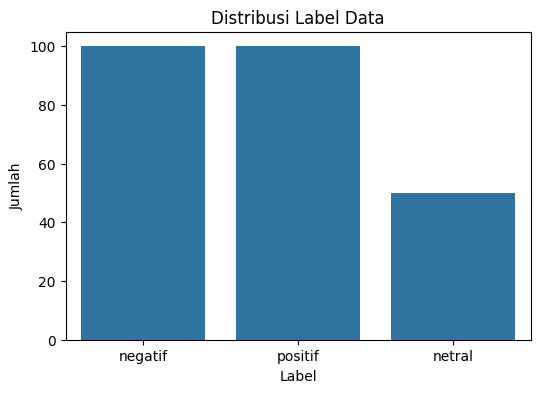

Accuracy: 0.7
              precision    recall  f1-score   support

     negatif       0.78      0.82      0.80        17
      netral       1.00      0.38      0.56        13
     positif       0.59      0.80      0.68        20

    accuracy                           0.70        50
   macro avg       0.79      0.67      0.68        50
weighted avg       0.76      0.70      0.69        50



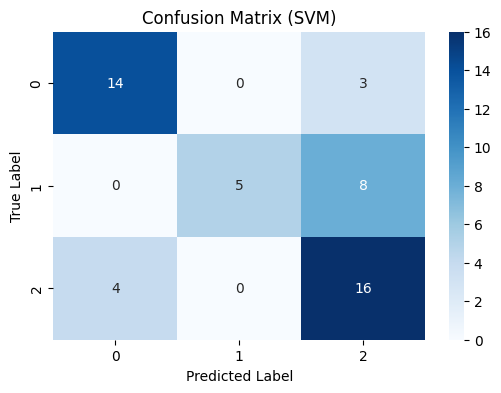

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# ============================
# 1. LOAD DATA
# ============================
df = pd.read_csv("/content/Data Label Manual 250.csv", sep=';')

# Ubah List String
df['Tokens_Final'] = df['Tokens_Final'].apply(lambda x: " ".join(ast.literal_eval(x)))

# Pakai Tokens_Final sebagai input
X = df['Tokens_Final']
y = df['Label']

# ============================
# 2. Visualisasi Label
# ============================
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribusi Label Data")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

# ============================
# 3. Train-test split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# 4. TF-IDF
# ============================
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ============================
# 5. MODEL SVM
# ============================
model = LinearSVC()
model.fit(X_train_tfidf, y_train)

# ============================
# 6. Prediksi
# ============================
pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# ============================
# 7. Confusion Matrix
# ============================
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


TF-IDF Logistic Regression

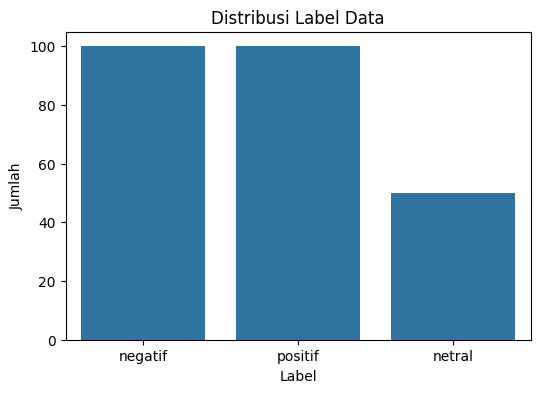

Accuracy: 0.58
              precision    recall  f1-score   support

     negatif       0.64      0.82      0.72        17
      netral       1.00      0.08      0.14        13
     positif       0.52      0.70      0.60        20

    accuracy                           0.58        50
   macro avg       0.72      0.53      0.49        50
weighted avg       0.68      0.58      0.52        50



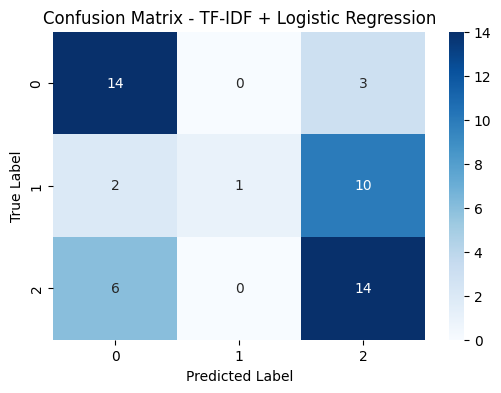

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. Load data
# ============================
df = pd.read_csv("/content/Data Label Manual 250.csv", sep=';')

# Ubah List String
df['Tokens_Final'] = df['Tokens_Final'].apply(eval)

# Fitur = gabungkan token menjadi string
X = df['Tokens_Final'].apply(lambda x: " ".join(x))
y = df['Label']

# ============================
# 2. Visualisasi distribusi label
# ============================
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribusi Label Data")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

# ============================
# 3. Train-test split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# 4. TF-IDF
# ============================
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ============================
# 5. Logistic Regression
# ============================
model = LogisticRegression(max_iter=300)
model.fit(X_train_tfidf, y_train)

# ============================
# 6. Prediksi
# ============================
pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# ============================
# 7. Confusion Matrix
# ============================
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


BoW SVM

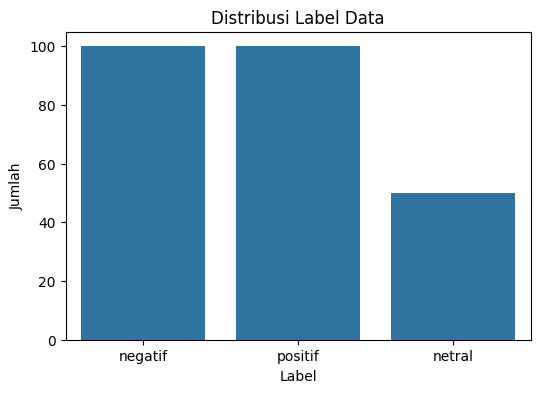

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.78
              precision    recall  f1-score   support

     negatif       0.82      0.82      0.82        17
      netral       1.00      0.62      0.76        13
     positif       0.68      0.85      0.76        20

    accuracy                           0.78        50
   macro avg       0.83      0.76      0.78        50
weighted avg       0.81      0.78      0.78        50



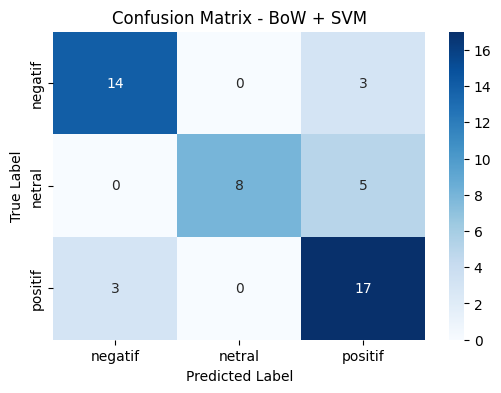

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 1. Load data
# ============================
df = pd.read_csv("/content/Data Label Manual 250.csv", sep=';')

# Ubah List String
df['Tokens_Final'] = df['Tokens_Final'].apply(eval)

tokens = df['Tokens_Final']
labels = df['Label']
texts = [" ".join(t) for t in tokens]

# ============================
# 2. Visualisasi distribusi label
# ============================
plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title("Distribusi Label Data")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

# ============================
# 3. Train-test split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# ============================
# 4. Ekstraksi Fitur BoW
# ============================
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ============================
# 5. Model SVM
# ============================
model = LinearSVC()
model.fit(X_train_vec, y_train)

# ============================
# 6. Prediksi
# ============================
pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# ============================
# 7. Confusion Matrix Visual
# ============================
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - BoW + SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


BoW Logistic Regression

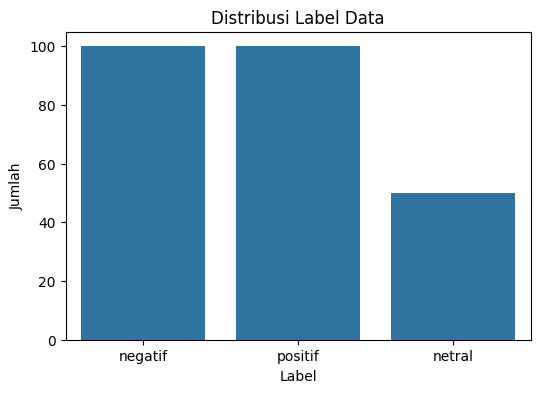

Accuracy: 0.72
              precision    recall  f1-score   support

     negatif       0.78      0.82      0.80        17
      netral       1.00      0.46      0.63        13
     positif       0.62      0.80      0.70        20

    accuracy                           0.72        50
   macro avg       0.80      0.70      0.71        50
weighted avg       0.77      0.72      0.71        50



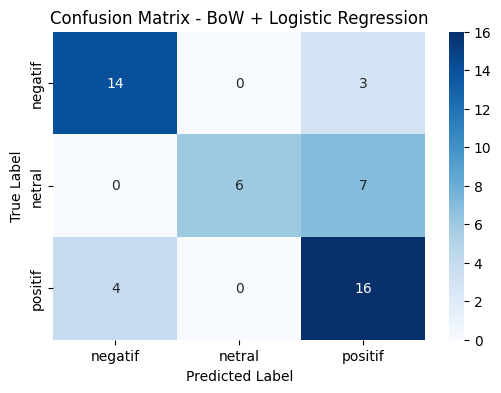

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 1. Load data
# ============================
df = pd.read_csv("/content/Data Label Manual 250.csv", sep=';')

# Ubah List String
df['Tokens_Final'] = df['Tokens_Final'].apply(eval)

tokens = df['Tokens_Final']
labels = df['Label']
texts = [" ".join(t) for t in tokens]

# ============================
# 2. Visualisasi distribusi label
# ============================
plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title("Distribusi Label Data")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

# ============================
# 3. Train-test split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# ============================
# 4. Ekstraksi Fitur BoW (CountVectorizer)
# ============================
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ============================
# 5. Model Logistic Regression
# ============================
model = LogisticRegression(max_iter=2000)
model.fit(X_train_vec, y_train)

# ============================
# 6. Prediksi
# ============================
pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# ============================
# 7. Confusion Matrix Visual
# ============================
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix - BoW + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
